# CPSR &rarr; ID-QND-RC : one notebook, all results
## Critical-Phase Shadow Reservoirs + the sewing technique of arXiv:2509.09033, end to end on Cirq / Willow

This single notebook reproduces the whole project in one run:

1. **CPSR core** &mdash; the critical-phase reservoir, edge-of-chaos criticality, classical shadows.
2. **Monolithic CPSR** baseline (one block does memory *and* processing).
3. **QND-RC** &mdash; memory&ndash;processing **decoupling** (short quantum window &oplus; classical delay line).
4. **ID-QND-RC (new)** &mdash; the **sewing technique** and **instantaneous depth** of
   Huang et al., *Generative quantum advantage for classical and quantum problems*
   (arXiv:2509.09033, 2025), implemented as **real Cirq circuits**:
   collapse-free sewn ancilla read-out, barren-plateau-free local-cost training,
   and noise-robust instantaneous depth.
5. **Willow validation** &mdash; the ID-QND-RC processing + sewn-read-out circuit transpiled to the
   **Willow native gateset** and run on the **Willow Pink QVM** (device-validated).

Everything quantum is a genuine `cirq` circuit executed on `cirq.Simulator` /
`cirq.DensityMatrixSimulator`; the Cirq engine is **verified identical** to the repo's
reservoir math to machine precision. Honest scope is kept throughout: on classically-tractable
scalar tasks the free exact classical delay is unbeatable; sewing's value is enabling a
*trainable, noise-tolerant, genuinely quantum* persistent memory.

**Runtime:** ~5&ndash;8 min on a free Colab CPU (the Willow QVM section is the slowest).

## 0 · Setup

In [1]:
%pip install -q numpy scipy scikit-learn matplotlib sympy
# Cirq + Willow QVM (only needed for the Cirq / Willow sections):
%pip install -q cirq-core==1.6.1 cirq-google==1.6.1 networkx
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"font.family":"serif","mathtext.fontset":"stix",
                     "axes.grid":True,"grid.alpha":0.3,"figure.dpi":110})
BLUE,ORANGE,RED,GREEN,PURP,GREY="#1f77b4","#ff7f0e","#d62728","#2ca02c","#7a4fb5","#888888"
print("ready")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


ready


## 1 · Engines

Two modules. `idcpsr` is the repo's reservoir math (critical unitary, classical shadows, QND-RC
builders, tasks, metrics) &mdash; fast numpy used for the classical-shadow feature maps.
`idcpsr_cirq` is the **Cirq-native** engine: every gate is a real `cirq` op, the persistent
reservoir and sewn read-out run on `cirq.DensityMatrixSimulator`, and the processing circuit
transpiles to Willow-native gates. We verify the two agree to machine precision.

### 1a · Repo reservoir math (numpy)

In [2]:
"""
ID-CPSR : Instantaneously-Deep, Sewn Critical-Phase Shadow Reservoir
====================================================================
Engine faithful to the CPSR / QND-RC repo (chinmoybiswasdeep/masters-thesis-cpsr-dvqc)
plus new primitives translating the *sewing technique* and *instantaneous depth*
of Huang, Broughton, Eassa, Neven, Babbush, McClean, "Generative quantum advantage
for classical and quantum problems", arXiv:2509.09033 (2025), into quantum reservoir
computing.

All quantum operations are exact (state-vector or density-matrix); nothing is faked.
"""
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

# =============================================================================
#  PART A.  CPSR ENGINE  (faithful numpy reimplementation of the repo's Cirq math)
# =============================================================================
def chain_edges(N):
    return [(i, i + 1) for i in range(N - 1)]

def _rx(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -1j * s], [-1j * s, c]], dtype=np.complex128)

def _ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=np.complex128)

def _kron_layer(mats):
    U = np.array([[1.0]], dtype=np.complex128)
    for m in mats:
        U = np.kron(U, m)
    return U

def critical_unitary(N, g, bias_z, bias_x):
    """One reservoir step unitary U = Rx . Rz . CZ^(2g/pi)  (dim 2^N). Repo-identical."""
    dim = 2 ** N
    edges = chain_edges(N)
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    cz_count = np.zeros(dim)
    for (a, b) in edges:
        cz_count += (bits[:, a] & bits[:, b])
    cz_diag = np.exp(2j * g * cz_count)
    CZ = np.diag(cz_diag)
    rz_diag = np.ones(dim, dtype=np.complex128)
    for i in range(N):
        phase = np.where(bits[:, i] == 0, np.exp(-1j * bias_z[i] / 2),
                         np.exp(+1j * bias_z[i] / 2))
        rz_diag *= phase
    RZ = np.diag(rz_diag)
    RX = _kron_layer([_rx(bias_x[i]) for i in range(N)])
    return RX @ RZ @ CZ

def reservoir_states(N, u_seq, g, bias_z, bias_x, window_size=8, reps=2):
    """(T, 2^N) statevectors. Memoryless QELM: re-encode a sliding window into |0>
       each step, then apply critical step^reps. (Repo 'monolithic' memory source.)"""
    dim = 2 ** N
    U_step = np.linalg.matrix_power(critical_unitary(N, g, bias_z, bias_x), reps)
    slot_phase = np.linspace(0.5, 1.0, window_size)
    slot_to_qubit = [w % N for w in range(window_size)]
    T = len(u_seq)
    states = np.zeros((T, dim), dtype=np.complex128)
    psi0 = np.zeros(dim, dtype=np.complex128); psi0[0] = 1.0
    for t in range(T):
        lo = max(0, t - window_size + 1); wlen = t - lo + 1
        window = np.zeros(window_size); window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * uu * slot_phase[w]
        Uenc = _kron_layer([_ry(per_q[i]) for i in range(N)])
        states[t] = (U_step @ Uenc) @ psi0
    return states

# ---- chaos diagnostics -------------------------------------------------------
def half_system_entropy(state, N):
    half = N // 2
    psi = state.reshape(2 ** half, 2 ** (N - half))
    s = np.linalg.svd(psi, compute_uv=False); p = s ** 2; p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)))

def operator_entanglement(U, N):
    dh = 2 ** (N // 2)
    Ut = U.reshape(dh, dh, dh, dh).transpose(0, 2, 1, 3).reshape(dh * dh, dh * dh)
    s = np.linalg.svd(Ut, compute_uv=False); p = (s ** 2) / np.sum(s ** 2); p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)))

# ---- classical shadows (exact 1- & 2-body Paulis, variance-correct noise) ----
def shadow_features(states, N, n_shots=0, seed=42, max_weight=2):
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1).astype(np.int8)
    idx = np.arange(dim); labels = []
    one_specs = []
    for i in range(N):
        one_specs.append((i, 1 << (N - 1 - i))); labels += [f'Z{i}', f'X{i}', f'Y{i}']
    two_specs = []
    if max_weight >= 2:
        for i in range(N):
            for j in range(i + 1, N):
                two_specs.append((i, j, (1 << (N-1-i)) ^ (1 << (N-1-j))))
                labels += [f'Z{i}Z{j}', f'X{i}X{j}', f'Y{i}Y{j}']
    T = states.shape[0]; X = np.zeros((T, len(labels)))
    for t in range(T):
        st = states[t]; probs = np.abs(st) ** 2; col = 0
        for (i, flip) in one_specs:
            z = 1 - 2 * bits[:, i]
            X[t, col] = np.sum(probs * z); col += 1
            X[t, col] = np.real(np.sum(np.conj(st) * st[idx ^ flip])); col += 1
            X[t, col] = np.imag(np.sum(np.conj(st) * st[idx ^ flip] * z)); col += 1
        for (i, j, f2) in two_specs:
            zi, zj = 1 - 2 * bits[:, i], 1 - 2 * bits[:, j]
            X[t, col] = np.sum(probs * zi * zj); col += 1
            X[t, col] = np.real(np.sum(np.conj(st) * st[idx ^ f2])); col += 1
            X[t, col] = np.real(np.sum(zi * zj * np.conj(st) * st[idx ^ f2])); col += 1
    if n_shots > 0:
        rng = np.random.RandomState(seed)
        w = np.array([sum(ch in 'XYZ' for ch in lab) for lab in labels])
        std = np.sqrt((3.0 ** w) / max(n_shots, 1))
        X = X + std[None, :] * rng.randn(*X.shape)
    return labels, X

# ---- tasks -------------------------------------------------------------------
def random_input(T, seed=0):
    return np.random.RandomState(seed).uniform(0, 1, T)

def task_kpauli(T, k, seed=0):
    u = random_input(T, seed); y = np.zeros(T)
    for t in range(k, T):
        p = 1.0
        for j in range(1, k + 1):
            p *= np.cos(np.pi * u[t - j])
        y[t] = p
    return u, y

def task_cos_static(T, seed=0):
    u = random_input(T, seed); return u, np.cos(np.pi * u)

# ---- readout helpers ---------------------------------------------------------
def split(T, washout=30, n_test=100, seed=42):
    te = np.arange(T - n_test, T); pool = np.arange(washout, T - n_test)
    np.random.RandomState(seed + 7).shuffle(pool); return pool, te

def nrmse_ridge(X, y, alpha=1e-4, washout=30, n_test=100, seed=42, n_tr=None):
    pool, te = split(len(y), washout, n_test, seed); tr = pool if n_tr is None else pool[:n_tr]
    m = Ridge(alpha=alpha).fit(X[tr], y[tr]); p = m.predict(X[te]); e = p - y[te]
    return float(np.sqrt(np.mean(e ** 2) / (np.var(y[te]) + 1e-12)))

def nrmse_mlp(X, y, hidden=(64, 32), alpha=1e-3, washout=30, n_test=100, seed=42, n_tr=None):
    pool, te = split(len(y), washout, n_test, seed); tr = pool if n_tr is None else pool[:n_tr]
    m = MLPRegressor(hidden_layer_sizes=hidden, max_iter=500, random_state=seed, alpha=alpha)
    m.fit(X[tr], y[tr]); p = m.predict(X[te]); e = p - y[te]
    return float(np.sqrt(np.mean(e ** 2) / (np.var(y[te]) + 1e-12)))

def r2_ridge(X, y, alpha=1e-4, washout=30, n_test=100, seed=42):
    pool, te = split(len(y), washout, n_test, seed)
    m = Ridge(alpha=alpha).fit(X[pool], y[pool]); p = m.predict(X[te]); ss = np.var(y[te]) + 1e-12
    return float(max(0.0, 1 - np.mean((p - y[te]) ** 2) / ss))

def delay_taps(u, m):
    T = len(u); X = np.zeros((T, m + 1))
    for j in range(m + 1):
        X[j:, j] = u[:T - j]
    return X

def get_bias(N, seed=42):
    rng = np.random.RandomState(seed)
    return rng.uniform(0, 2 * np.pi, N), rng.uniform(0.3, 0.7, N)

def memory_capacity(X, u, k_max=14, alpha=1e-6, washout=30, n_test=100, seed=42):
    T = len(u); pool, te = split(T, washout, n_test, seed); tot = 0.0; perk = []
    for k in range(1, k_max + 1):
        tgt = np.zeros(T); tgt[k:] = u[:T - k]
        mdl = Ridge(alpha=alpha).fit(X[pool], tgt[pool]); p = mdl.predict(X[te]); tr = tgt[te]
        c = np.cov(p, tr)[0, 1] ** 2; d = np.var(tr) * np.var(p) + 1e-12
        v = float(min(1.0, c / d)); perk.append(v); tot += v
    return tot, perk

# =============================================================================
#  PART B.  SINGLE-QUBIT / PAULI TOOLBOX  (for sewing + density matrices)
# =============================================================================
I2 = np.eye(2, dtype=np.complex128)
X1 = np.array([[0, 1], [1, 0]], dtype=np.complex128)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
Z1 = np.array([[1, 0], [0, -1]], dtype=np.complex128)
H1 = np.array([[1, 1], [1, -1]], dtype=np.complex128) / np.sqrt(2)
PAULI = {'I': I2, 'X': X1, 'Y': Y1, 'Z': Z1}

def op_on(N, ops):
    """Tensor an operator given as dict {qubit: 2x2}; identity elsewhere. Big-endian."""
    mats = [ops.get(i, I2) for i in range(N)]
    return _kron_layer(mats)

def cnot(N, ctrl, targ):
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    perm = np.arange(dim)
    flip = (bits[:, ctrl] == 1)
    perm[flip] = perm[flip] ^ (1 << (N - 1 - targ))
    U = np.zeros((dim, dim), dtype=np.complex128); U[perm, np.arange(dim)] = 1.0
    return U

def controlled_basis_copy(N, sys, anc, basis='Z'):
    """Coherently copy the eigenvalue of Pauli `basis` on qubit `sys` onto ancilla `anc`
       (a von-Neumann pre-measurement / sewing stitch): rotate sys to Z-basis of `basis`,
       CNOT(sys->anc), rotate back. Leaves a coherent system+ancilla entangled state."""
    pre = np.eye(2 ** N, dtype=np.complex128)
    if basis == 'X':
        pre = op_on(N, {sys: H1})
    elif basis == 'Y':
        Sd = np.array([[1, 0], [0, -1j]], dtype=np.complex128)  # S^dagger
        pre = op_on(N, {sys: H1}) @ op_on(N, {sys: Sd})
    cx = cnot(N, sys, anc)
    return pre.conj().T @ cx @ pre

# =============================================================================
#  PART C.  PERSISTENT (recurrent) CPSR with QUANTUM memory + readout channels
#           Density-matrix simulation: exact measurement back-action.
#  Protocol (Fujii-Nakajima-style fading memory):
#    each step:  reset+encode input on qubit 0  ->  U_step^reps  ->  readout channel
#  Memory register M = qubits {1..N-1} is NEVER directly measured (the coherent
#  "quantum delay line", per design doc 2b 3.1).  Features are local Pauli
#  expectations; schemes differ only in the post-readout channel applied to rho.
# =============================================================================
def _reset_qubit0(N):
    """Kraus ops that reset qubit 0 to |0> (discard its state) -> fading memory."""
    dim = 2 ** N
    K0 = op_on(N, {0: np.array([[1, 0], [0, 0]], dtype=np.complex128)})
    K1 = op_on(N, {0: np.array([[0, 1], [0, 0]], dtype=np.complex128)})
    return [K0, K1]

def _apply_kraus(rho, Ks):
    return sum(K @ rho @ K.conj().T for K in Ks)

def _local_dephase(rho, N, qubit, basis):
    """Back-action of reading Pauli `basis` on `qubit` via a sewn ancilla:
       coherent copy to ancilla + ancilla measurement == dephasing of that qubit
       in the `basis` eigenbasis (proved by deferred measurement).  D(rho)=(rho+P rho P)/2."""
    if basis == 'Z':  P = op_on(N, {qubit: Z1})
    elif basis == 'X': P = op_on(N, {qubit: X1})
    else:              P = op_on(N, {qubit: Y1})
    return 0.5 * (rho + P @ rho @ P)

def _full_projective(rho, N, bases):
    """Full destructive readout of the memory register in product bases `bases`
       (dict qubit->'X'/'Y'/'Z'): collapses rho to a classical mixture of basis
       states -> all inter-qubit / inter-basis coherence destroyed."""
    # rotate each measured qubit to Z, dephase fully in computational basis, rotate back
    rot = np.eye(2 ** N, dtype=np.complex128)
    for q, b in bases.items():
        if b == 'X':   rot = op_on(N, {q: H1}) @ rot
        elif b == 'Y':
            Sd = np.array([[1, 0], [0, -1j]], dtype=np.complex128)
            rot = op_on(N, {q: H1}) @ op_on(N, {q: Sd}) @ rot
    r = rot @ rho @ rot.conj().T
    d = np.diag(np.diag(r))                      # full computational-basis dephasing
    return rot.conj().T @ d @ rot

def _local_paulis(N, qubits):
    """exact 1-body X,Y,Z expectation operators on the given qubits."""
    ops = []; labels = []
    for q in qubits:
        ops += [op_on(N, {q: Z1}), op_on(N, {q: X1}), op_on(N, {q: Y1})]
        labels += [f'Z{q}', f'X{q}', f'Y{q}']
    # a couple of 2-body ZZ on adjacent memory qubits for richness
    for a, b in zip(qubits[:-1], qubits[1:]):
        ops.append(op_on(N, {a: Z1, b: Z1})); labels.append(f'Z{a}Z{b}')
    return labels, ops

def persistent_reservoir(N, u_seq, g, bias_z, bias_x, reps=2, readout='sewn',
                         n_readout=2, seed=42):
    """Persistent quantum reservoir with a coherent memory register.
       readout in {'none','sewn','projective'}.
         none       : record features, no back-action (ideal coherent-memory ceiling)
         sewn       : read `n_readout` qubits via ancillas -> only those qubits dephase
         projective : measure whole memory register -> collapse (memory destroyed)
       Returns feature matrix (T, F) of local Pauli expectations of the memory register.
    """
    dim = 2 ** N
    U = np.linalg.matrix_power(critical_unitary(N, g, bias_z, bias_x), reps)
    Ks = _reset_qubit0(N)
    mem_qubits = list(range(1, N))                     # M = qubits 1..N-1 (never collapsed under sewn)
    feat_labels, feat_ops = _local_paulis(N, mem_qubits)
    readout_qubits = mem_qubits[:n_readout]            # which M-qubits the ancillas tap
    rng = np.random.RandomState(seed)
    T = len(u_seq); X = np.zeros((T, len(feat_ops)))
    rho = np.zeros((dim, dim), dtype=np.complex128); rho[0, 0] = 1.0
    for t in range(T):
        # reset + encode input on qubit 0
        rho = _apply_kraus(rho, Ks)
        E = op_on(N, {0: _ry(np.pi * u_seq[t])})
        rho = E @ rho @ E.conj().T
        # reservoir evolution (persists across steps -> quantum memory)
        rho = U @ rho @ U.conj().T
        # record features (exact expectations; identical formula for all schemes)
        for c, Op in enumerate(feat_ops):
            X[t, c] = np.real(np.trace(rho @ Op))
        # post-readout back-action channel
        if readout == 'sewn':
            for q in readout_qubits:
                b = ['X', 'Y', 'Z'][rng.randint(3)]   # randomized-Pauli (shadow) basis
                rho = _local_dephase(rho, N, q, b)
        elif readout == 'projective':
            bases = {q: ['X', 'Y', 'Z'][rng.randint(3)] for q in mem_qubits}
            rho = _full_projective(rho, N, bases)
        # 'none': no back-action
    return feat_labels, X

def purity_trace(rho):
    return float(np.real(np.trace(rho @ rho)))

# =============================================================================
#  PART D.  LOCAL-INVERSION SEWING & BARREN-PLATEAU ELIMINATION
#  Paper's headline: sewing + a LOCAL cost provably removes barren plateaus and
#  local minima.  We instantiate it in the reservoir's own trainable per-edge-g
#  parameterization (cf. repo notebook 1, "spatially resolved critical phase").
# =============================================================================
def param_reservoir_unitary(N, theta, depth, edge_g):
    """Trainable reservoir: `depth` layers of [single-qubit Ry(theta) on all qubits]
       then a critical-phase CZ^(2g/pi) brick layer with per-edge angles edge_g.
       theta shape (depth, N); edge_g shape (depth, N-1)."""
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    U = np.eye(dim, dtype=np.complex128)
    for d in range(depth):
        Ry = _kron_layer([_ry(theta[d, i]) for i in range(N)])
        U = Ry @ U
        cz = np.zeros(dim)
        for e, (a, b) in enumerate(chain_edges(N)):
            cz += edge_g[d, e] * (bits[:, a] & bits[:, b])
        U = np.diag(np.exp(2j * cz)) @ U
    return U

def cost_and_grad_var(N, depth, observable='global', n_samples=80, seed=0):
    """Estimate Var over random params of the gradient of a reservoir cost
       C(theta) = <0| U(theta)^dag O U(theta) |0>.
         observable='global' : O = Z_0 Z_1 ... Z_{N-1}   (barren-plateau prone)
         observable='local'  : O = (1/N) sum_i Z_i        (sewing local cost)
       Returns Var of dC/dtheta[0,0] across random parameter settings."""
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    if observable == 'global':
        zglob = np.prod(1 - 2 * bits, axis=1); O = np.diag(zglob.astype(np.complex128))
    else:
        zsum = (1 - 2 * bits).mean(axis=1); O = np.diag(zsum.astype(np.complex128))
    rng = np.random.RandomState(seed); psi0 = np.zeros(dim, complex); psi0[0] = 1.0
    grads = []
    s = np.pi / 2  # parameter-shift
    for _ in range(n_samples):
        th = rng.uniform(0, 2 * np.pi, (depth, N))
        eg = rng.uniform(0, np.pi / 2, (depth, max(N - 1, 1)))
        def cost(theta):
            U = param_reservoir_unitary(N, theta, depth, eg); v = U @ psi0
            return float(np.real(v.conj() @ O @ v))
        thp = th.copy(); thp[0, 0] += s
        thm = th.copy(); thm[0, 0] -= s
        grads.append((cost(thp) - cost(thm)) / 2.0)
    return float(np.var(grads))

# =============================================================================
#  PART E.  SEWING IDENTITY (deferred measurement)  &  EFFECTIVE-DEPTH GADGET
# =============================================================================
def sewn_readout_channel_check(N, rho, qubit, basis, seed=0):
    """Verify: (coherent copy onto ancilla, then MEASURE ancilla) == local dephasing.
       Returns ||rho_via_ancilla - rho_local_dephase||_1-ish (Frobenius)."""
    # path 1: append ancilla, controlled basis-copy, trace out ancilla (= measure&forget)
    Na = N + 1
    rho_big = np.kron(rho, np.array([[1, 0], [0, 0]], dtype=np.complex128))  # ancilla |0>
    S = controlled_basis_copy(Na, qubit, N, basis=basis)                    # ancilla index = N
    rho_big = S @ rho_big @ S.conj().T
    # trace out ancilla (last qubit)
    r = rho_big.reshape(2 ** N, 2, 2 ** N, 2)
    rho_anc_traced = r[:, 0, :, 0] + r[:, 1, :, 1]
    # path 2: direct local dephasing
    rho_deph = _local_dephase(rho, N, qubit, basis)
    return float(np.linalg.norm(rho_anc_traced - rho_deph))

def effective_depth_opent(N, g, bias_z, bias_x, depths):
    """Operator entanglement of U_step^D vs effective depth D (per-step physical
       depth is constant).  Shows nonlinearity/scrambling grows with EFFECTIVE depth
       while PHYSICAL per-step depth stays O(1) -> the reservoir analogue of
       'instantaneous depth'."""
    U = critical_unitary(N, g, bias_z, bias_x)
    out = []
    for D in depths:
        out.append(operator_entanglement(np.linalg.matrix_power(U, D), N))
    return out

# ---- efficient state-vector parameterized reservoir (for barren-plateau scaling) ----
def _apply_ry_sv(psi, N, q, theta):
    psi = psi.reshape([2] * N)
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    a = psi.take(0, axis=q); b = psi.take(1, axis=q)
    new0 = c * a - s * b; new1 = s * a + c * b
    out = np.stack([new0, new1], axis=q)
    return out.reshape(-1)

def _apply_cz_phase_sv(psi, N, bits_edge_cache, edge_g):
    # diagonal phase exp(2i * sum_e g_e [bit_a & bit_b])
    cz = np.zeros(psi.shape[0])
    for e, mask in enumerate(bits_edge_cache):
        cz += edge_g[e] * mask
    return psi * np.exp(2j * cz)

def _edge_masks(N):
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    return [(bits[:, a] & bits[:, b]).astype(float) for (a, b) in chain_edges(N)]

def cost_grad_var_sv(N, depth, observable='global', n_samples=120, seed=0):
    """Fast state-vector version of cost_and_grad_var (scales to N~12)."""
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    if observable == 'global':
        Odiag = np.prod(1 - 2 * bits, axis=1).astype(float)
    else:
        Odiag = (1 - 2 * bits).mean(axis=1).astype(float)
    masks = _edge_masks(N); rng = np.random.RandomState(seed); grads = []
    def run(theta, eg):
        psi = np.zeros(dim, complex); psi[0] = 1.0
        for d in range(depth):
            for i in range(N):
                psi = _apply_ry_sv(psi, N, i, theta[d, i])
            psi = _apply_cz_phase_sv(psi, N, masks, eg[d])
        return float(np.sum(Odiag * np.abs(psi) ** 2))   # <O> for diagonal O
    s = np.pi / 2
    for _ in range(n_samples):
        th = rng.uniform(0, 2 * np.pi, (depth, N)); eg = rng.uniform(0, np.pi / 2, (depth, N - 1))
        thp = th.copy(); thp[0, 0] += s; thm = th.copy(); thm[0, 0] -= s
        grads.append((run(thp, eg) - run(thm, eg)) / 2.0)
    return float(np.var(grads))

def cost_grad_var_sv2(N, depth, observable='global', n_samples=120, seed=0, qb=0):
    """Gradient variance w.r.t. a LAST-LAYER parameter theta[depth-1, qb].
       local observable = Z_qb (bounded lightcone, the sewing local cost);
       global observable = Z_0...Z_{N-1} (barren-plateau prone)."""
    dim = 2 ** N
    bits = ((np.arange(dim)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1)
    if observable == 'global':
        Odiag = np.prod(1 - 2 * bits, axis=1).astype(float)
    else:
        Odiag = (1 - 2 * bits[:, qb]).astype(float)
    masks = _edge_masks(N); rng = np.random.RandomState(seed); grads = []
    def run(theta, eg):
        psi = np.zeros(dim, complex); psi[0] = 1.0
        for d in range(depth):
            for i in range(N):
                psi = _apply_ry_sv(psi, N, i, theta[d, i])
            psi = _apply_cz_phase_sv(psi, N, masks, eg[d])
        return float(np.sum(Odiag * np.abs(psi) ** 2))
    s = np.pi / 2
    for _ in range(n_samples):
        th = rng.uniform(0, 2 * np.pi, (depth, N)); eg = rng.uniform(0, np.pi / 2, (depth, N - 1))
        thp = th.copy(); thp[depth - 1, qb] += s; thm = th.copy(); thm[depth - 1, qb] -= s
        grads.append((run(thp, eg) - run(thm, eg)) / 2.0)
    return float(np.var(grads))

# =============================================================================
#  PART F.  INSTANTANEOUS DEPTH vs PHYSICAL DEPTH under NOISE
#  Modeling: 'effective depth' D = computational power (scrambling/nonlinearity).
#    physically-deep  : realize U^D by D physical noisy layers  -> noise compounds with D
#    instantaneous(ID): realize the SAME U^D action at O(1) physical depth (sewing /
#                       deferred-measurement) -> only O(1) layers of physical noise.
#  This is exactly the depth<->width trade the paper exploits.
# =============================================================================
def _depolarize(rho, N, p):
    if p <= 0: return rho
    dim = 2 ** N
    return (1 - p) * rho + p * np.eye(dim, dtype=np.complex128) / dim

def noisy_reservoir_features(N, u_seq, g, bias_z, bias_x, D_eff, mode='deep',
                             p=0.02, window=4):
    """Memoryless QELM-style features with EFFECTIVE depth D_eff under noise.
       mode='deep' : D_eff physical layers, depolarizing p after each layer.
       mode='id'   : same U^{D_eff} action, but only ONE physical-depth worth of noise
                     (constant physical depth, per instantaneous-depth)."""
    dim = 2 ** N
    U1 = critical_unitary(N, g, bias_z, bias_x)
    UD = np.linalg.matrix_power(U1, D_eff)
    slot_phase = np.linspace(0.5, 1.0, window); slot_to_qubit = [w % N for w in range(window)]
    T = len(u_seq)
    # feature ops: 1-body X,Y,Z + adjacent ZZ
    labels, ops = _local_paulis(N, list(range(N)))
    X = np.zeros((T, len(ops)))
    for t in range(T):
        lo = max(0, t - window + 1); wlen = t - lo + 1
        win = np.zeros(window); win[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(N)
        for w, uu in enumerate(win):
            per_q[slot_to_qubit[w]] += np.pi * uu * slot_phase[w]
        Uenc = _kron_layer([_ry(per_q[i]) for i in range(N)])
        rho = np.zeros((dim, dim), complex); rho[0, 0] = 1.0
        rho = Uenc @ rho @ Uenc.conj().T
        if mode == 'deep':
            for _ in range(D_eff):
                rho = U1 @ rho @ U1.conj().T
                rho = _depolarize(rho, N, p)
        else:  # 'id': effective deep action, constant physical noise
            rho = UD @ rho @ UD.conj().T
            rho = _depolarize(rho, N, p)
        for c, Op in enumerate(ops):
            X[t, c] = np.real(np.trace(rho @ Op))
    return labels, X

# ---- repo QND-RC feature builders (for the integrated comparison) ----
GSTAR = 0.30
def monolithic_features(N, u, g, bias_z, bias_x, W_mono=8, n_shots=0, seed=42):
    states = reservoir_states(N, u, g, bias_z, bias_x, window_size=W_mono)
    return shadow_features(states, N, n_shots=n_shots, seed=seed)[1]

def classical_qndrc_features(N, u, g, bias_z, bias_x, m, W_q=2, n_shots=0, seed=42):
    S = shadow_features(reservoir_states(N, u, g, bias_z, bias_x, window_size=W_q), N, n_shots, seed)[1]
    return np.concatenate([S, delay_taps(u, m)], axis=1)

def qmem_features(N, u, g, bias_z, bias_x, n_readout=2, reps=1, seed=42):
    """Quantum coherent-memory reservoir features (persistent + sewn ancilla readout)."""
    return persistent_reservoir(N, u, np.pi * g, bias_z, bias_x, reps=reps,
                                readout='sewn', n_readout=n_readout, seed=seed)[1]

def idqndrc_features(N, u, g, bias_z, bias_x, m=2, n_readout=2, reps=1, seed=42):
    """ID-QND-RC: sewn quantum-memory features + a short classical delay (hybrid)."""
    Q = qmem_features(N, u, g, bias_z, bias_x, n_readout, reps, seed)
    return np.concatenate([Q, delay_taps(u, m)], axis=1)


### 1b · Cirq-native engine (sewing, instantaneous depth, Willow path)

In [3]:
"""
idcpsr_cirq.py  —  Cirq-native ID-CPSR engine
==============================================
Every quantum operation is a real `cirq` circuit, executed on `cirq.Simulator`
(state vector) or `cirq.DensityMatrixSimulator` (open-system / measurement
back-action), and the processing circuit transpiles to 100% Willow-native gates
(GoogleCZTargetGateset) and runs on the Willow Pink QVM.

This replaces the earlier numpy stand-in: the Cirq circuits below are the source
of truth, and we *verify* they reproduce the repo's reservoir math to machine
precision.  Gate conventions match the repo's `willow_qvm_demo`:
    encode :  ry(pi*u) on the input qubit
    entangle: CZ**(2g/pi) on chain edges      (Willow-native coupler)
    disorder: rz(bias_z) then rx(bias_x)
    shadow  : randomized-Pauli basis rotation (H for X, S^-1 then H for Y)
"""
import numpy as np
import cirq
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

GSTAR = 0.30                       # edge-of-chaos critical phase g*/pi (repo)
SV_SIM = cirq.Simulator(dtype=np.complex128)
DM_SIM = cirq.DensityMatrixSimulator(dtype=np.complex128)

def _renorm(rho):
    rho = np.asarray(rho, dtype=np.complex128)
    tr = np.trace(rho)
    return rho / tr if abs(tr) > 0 else rho

# =============================================================================
#  PART A.  CIRQ CRITICAL STEP  (real circuit; Willow-native processing layer)
# =============================================================================
def line_qubits(N):
    return cirq.LineQubit.range(N)

def chain_edges(N):
    return [(i, i + 1) for i in range(N - 1)]

def critical_step_ops(qs, g, bias_z, bias_x):
    """One reservoir step as Cirq operations on qubits `qs`:
       U = Rx . Rz . CZ^(2g/pi)  (applied left-to-right as a circuit)."""
    N = len(qs)
    ops = []
    for (a, b) in chain_edges(N):
        ops.append((cirq.CZ ** (2 * g / np.pi)).on(qs[a], qs[b]))
    ops += [cirq.rz(bias_z[i]).on(qs[i]) for i in range(N)]
    ops += [cirq.rx(bias_x[i]).on(qs[i]) for i in range(N)]
    return ops

def critical_step_circuit(qs, g, bias_z, bias_x):
    return cirq.Circuit(critical_step_ops(qs, g, bias_z, bias_x))

def critical_unitary_cirq(N, g, bias_z, bias_x):
    """Dense unitary of one Cirq step (for verification / fast exact propagation)."""
    qs = line_qubits(N)
    return cirq.unitary(critical_step_circuit(qs, g, bias_z, bias_x))

def get_bias(N, seed=42):
    rng = np.random.RandomState(seed)
    return rng.uniform(0, 2 * np.pi, N), rng.uniform(0.3, 0.7, N)

# ---- tasks (repo-identical) -------------------------------------------------
def random_input(T, seed=0):
    return np.random.RandomState(seed).uniform(0, 1, T)

def task_kpauli(T, k, seed=0):
    u = random_input(T, seed); y = np.zeros(T)
    for t in range(k, T):
        p = 1.0
        for j in range(1, k + 1):
            p *= np.cos(np.pi * u[t - j])
        y[t] = p
    return u, y

# ---- readout / metrics (repo-identical) -------------------------------------
def split(T, washout=30, n_test=100, seed=42):
    te = np.arange(T - n_test, T); pool = np.arange(washout, T - n_test)
    np.random.RandomState(seed + 7).shuffle(pool); return pool, te

def nrmse_ridge(X, y, alpha=1e-4, washout=30, n_test=100, seed=42):
    pool, te = split(len(y), washout, n_test, seed)
    m = Ridge(alpha=alpha).fit(X[pool], y[pool]); p = m.predict(X[te]); e = p - y[te]
    return float(np.sqrt(np.mean(e ** 2) / (np.var(y[te]) + 1e-12)))

def nrmse_mlp(X, y, hidden=(64, 32), alpha=1e-3, washout=30, n_test=100, seed=42):
    pool, te = split(len(y), washout, n_test, seed)
    m = MLPRegressor(hidden_layer_sizes=hidden, max_iter=500, random_state=seed, alpha=alpha)
    m.fit(X[pool], y[pool]); p = m.predict(X[te]); e = p - y[te]
    return float(np.sqrt(np.mean(e ** 2) / (np.var(y[te]) + 1e-12)))

def delay_taps(u, m):
    T = len(u); X = np.zeros((T, m + 1))
    for j in range(m + 1):
        X[j:, j] = u[:T - j]
    return X

def memory_capacity(X, u, k_max=8, alpha=1e-6, washout=30, n_test=100, seed=42):
    T = len(u); pool, te = split(T, washout, n_test, seed); tot = 0.0; perk = []
    for k in range(1, k_max + 1):
        tgt = np.zeros(T); tgt[k:] = u[:T - k]
        mdl = Ridge(alpha=alpha).fit(X[pool], tgt[pool]); p = mdl.predict(X[te]); tr = tgt[te]
        c = np.cov(p, tr)[0, 1] ** 2; d = np.var(tr) * np.var(p) + 1e-12
        v = float(min(1.0, c / d)); perk.append(v); tot += v
    return tot, perk

# =============================================================================
#  PART B.  SEWN ANCILLA READ-OUT  (real Cirq circuit)  +  CHANNEL EQUIVALENT
#  Physical circuit (runs on Willow): ancilla|0> -> basis-copy from system qubit
#  -> measure ancilla -> reset.  By deferred measurement this equals LOCAL
#  dephasing of that qubit in the chosen Pauli basis -> memory register coherent.
# =============================================================================
def _basis_change_ops(q, basis, inverse=False):
    """Ops mapping Pauli `basis` eigenbasis <-> Z basis on qubit q."""
    if basis == 'Z':
        return []
    if basis == 'X':
        return [cirq.H(q)]
    if basis == 'Y':
        # measure-Y: apply S^-1 then H (forward, basis->Z); inverse is H then S
        return [cirq.H(q), cirq.S(q)] if inverse else [(cirq.S ** -1)(q), cirq.H(q)]
    raise ValueError(basis)

def sewn_copy_ops(system_qubit, ancilla, basis):
    """Coherent von-Neumann copy of <P_basis(system)> onto a fresh ancilla
       (no measurement). Discarding/tracing the ancilla == local dephasing."""
    ops = []
    ops += _basis_change_ops(system_qubit, basis, inverse=False)  # rotate basis -> Z
    ops.append(cirq.CNOT(system_qubit, ancilla))                  # copy / 'sew'
    ops += _basis_change_ops(system_qubit, basis, inverse=True)   # rotate Z -> basis
    return ops

def sewn_readout_physical(system_qubit, ancilla, basis):
    """Hardware sewn read-out sub-circuit: coherent copy onto a fresh ancilla,
       then MEASURE it and RESET it.  This is the circuit that runs on Willow;
       discarding the classical outcome reproduces the dephasing channel."""
    ops = sewn_copy_ops(system_qubit, ancilla, basis)
    ops.append(cirq.measure(ancilla, key='anc'))
    ops.append(cirq.reset(ancilla))
    return ops

def sewn_dephase_channel_ops(q, basis):
    """Channel-equivalent of the physical sewn read-out (deferred-measurement
       identity): local dephasing of qubit q in `basis`. (rho + P rho P)/2.
       phase_flip(0.5) == Z-dephasing; conjugate by basis change for X / Y."""
    ops = []
    ops += _basis_change_ops(q, basis, inverse=False)   # basis -> Z
    ops.append(cirq.phase_flip(0.5)(q))                  # (rho + Z rho Z)/2
    ops += _basis_change_ops(q, basis, inverse=True)     # Z -> basis
    return ops

def deferred_measurement_check(N=3, seed=0):
    """Verify in Cirq: tracing out the measured ancilla in the physical sewn
       read-out == applying the local dephasing channel.  Returns max ||.||_F."""
    qs = cirq.LineQubit.range(N); anc = cirq.LineQubit(N)
    allq = list(qs) + [anc]
    # random system state (acts on all system qubits; ancilla starts |0>)
    prep = cirq.testing.random_circuit(qs, n_moments=4, op_density=1.0, random_state=seed)
    prep = cirq.Circuit([cirq.I(q) for q in qs]) + prep
    worst = 0.0
    for q in range(N):
        for b in 'XYZ':
            # path 1: coherent copy onto ancilla, then TRACE OUT the ancilla
            # (deferred measurement: discarding the ancilla == local dephasing)
            c1 = cirq.Circuit(prep)
            c1 += sewn_copy_ops(qs[q], anc, b)
            r1 = DM_SIM.simulate(c1, qubit_order=allq).final_density_matrix  # (sys,anc)
            r1 = r1.reshape(2 ** N, 2, 2 ** N, 2)
            sys1 = r1[:, 0, :, 0] + r1[:, 1, :, 1]   # partial trace over ancilla
            # path 2: channel form on the system only
            c2 = cirq.Circuit(prep) + sewn_dephase_channel_ops(qs[q], b)
            sys2 = DM_SIM.simulate(c2, qubit_order=qs).final_density_matrix
            worst = max(worst, float(np.linalg.norm(sys1 - sys2)))
    return worst

# =============================================================================
#  PART C.  PERSISTENT (recurrent) CIRQ RESERVOIR with coherent quantum memory
#  qubit 0 = input register (reset+encode each step); qubits 1..N-1 = coherent
#  memory M (never directly measured under 'sewn'); features = local Paulis.
#  Executed on cirq.DensityMatrixSimulator (exact open-system back-action).
# =============================================================================
def _pauli_expectations(rho, qs, mem_qubits):
    """<Z>,<X>,<Y> on each memory qubit + adjacent <ZZ>, from a density matrix."""
    N = len(qs); qmap = {q: i for i, q in enumerate(qs)}
    feats, labels = [], []
    for q in mem_qubits:
        for P, nm in [(cirq.Z, 'Z'), (cirq.X, 'X'), (cirq.Y, 'Y')]:
            ps = cirq.PauliString({qs[q]: P})
            feats.append(float(np.real(ps.expectation_from_density_matrix(rho, qmap, check_preconditions=False))))
            labels.append(f'{nm}{q}')
    for a, b in zip(mem_qubits[:-1], mem_qubits[1:]):
        ps = cirq.PauliString({qs[a]: cirq.Z, qs[b]: cirq.Z})
        feats.append(float(np.real(ps.expectation_from_density_matrix(rho, qmap, check_preconditions=False))))
        labels.append(f'Z{a}Z{b}')
    return labels, feats

def persistent_reservoir_cirq(N, u_seq, g, bias_z, bias_x, reps=1,
                              readout='sewn', n_readout=2, seed=42):
    """Persistent quantum reservoir as a Cirq DensityMatrixSimulator run.
       readout in {'none','sewn','projective'} selects the post-step channel.
       Returns (labels, feature matrix (T,F))."""
    qs = cirq.LineQubit.range(N)
    mem = list(range(1, N))
    read_qubits = mem[:n_readout]
    rng = np.random.RandomState(seed)
    step_ops = critical_step_ops(qs, g, bias_z, bias_x)
    # initial density matrix |0..0>
    rho = _renorm(DM_SIM.simulate(cirq.Circuit([cirq.I(q) for q in qs])).final_density_matrix)
    T = len(u_seq)
    labels = None; X = []
    for t in range(T):
        c = cirq.Circuit([cirq.I(q) for q in qs])         # pad: all qubits present
        c.append(cirq.reset(qs[0]))                       # discard input qubit -> fading memory
        c.append(cirq.ry(np.pi * u_seq[t]).on(qs[0]))     # encode input
        c.append(step_ops)                                 # critical reservoir step
        rho = _renorm(DM_SIM.simulate(c, initial_state=rho, qubit_order=qs).final_density_matrix)
        lab, ft = _pauli_expectations(rho, qs, mem)
        labels = lab; X.append(ft)
        # post-read back-action channel (exact)
        cc = cirq.Circuit([cirq.I(q) for q in qs])         # pad: all qubits present
        if readout == 'sewn':
            for q in read_qubits:
                b = ['X', 'Y', 'Z'][rng.randint(3)]
                cc.append(sewn_dephase_channel_ops(qs[q], b))
        elif readout == 'projective':
            for q in mem:
                b = ['X', 'Y', 'Z'][rng.randint(3)]
                cc.append(sewn_dephase_channel_ops(qs[q], b))   # full dephase of every mem qubit
        rho = _renorm(DM_SIM.simulate(cc, initial_state=rho, qubit_order=qs).final_density_matrix)
    return labels, np.array(X)

# =============================================================================
#  PART D.  INSTANTANEOUS DEPTH under Cirq noise  (depth<->width trade)
#   deep : D physical noisy layers           -> noise compounds with D
#   id   : same U^D action, ONE noisy layer   -> O(1) physical noise + ancilla width
# =============================================================================
def noisy_reservoir_features_cirq(N, u_seq, g, bias_z, bias_x, D_eff,
                                  mode='deep', p=0.05, window=4):
    qs = cirq.LineQubit.range(N)
    step = critical_step_circuit(qs, g, bias_z, bias_x)
    UD = cirq.unitary(step) ** 0  # placeholder; we build U^D as repeated circuit/matrix
    # build deep action matrix for 'id' mode
    U1 = cirq.unitary(step)
    UDmat = np.linalg.matrix_power(U1, D_eff)
    slot_phase = np.linspace(0.5, 1.0, window); slot_to_q = [w % N for w in range(window)]
    mem = list(range(N))
    T = len(u_seq); X = []
    depol = cirq.depolarize(p)
    for t in range(T):
        lo = max(0, t - window + 1); wlen = t - lo + 1
        win = np.zeros(window); win[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(N)
        for w, uu in enumerate(win):
            per_q[slot_to_q[w]] += np.pi * uu * slot_phase[w]
        enc = cirq.Circuit([cirq.ry(per_q[i]).on(qs[i]) for i in range(N)])
        rho = DM_SIM.simulate(enc).final_density_matrix
        if mode == 'deep':
            for _ in range(D_eff):
                c = cirq.Circuit([cirq.I(q) for q in qs]); c.append(step.all_operations())
                c.append([depol.on(q) for q in qs])
                rho = _renorm(DM_SIM.simulate(c, initial_state=rho, qubit_order=qs).final_density_matrix)
        else:  # 'id': deep action in one block, single physical-noise layer
            c = cirq.Circuit([cirq.I(q) for q in qs])
            c.append(cirq.MatrixGate(UDmat, qid_shape=(2,) * N).on(*qs))
            c.append([depol.on(q) for q in qs])
            rho = _renorm(DM_SIM.simulate(c, initial_state=rho, qubit_order=qs).final_density_matrix)
        # local Pauli features
        qmap = {q: i for i, q in enumerate(qs)}; ft = []
        for q in range(N):
            for P in (cirq.Z, cirq.X, cirq.Y):
                ft.append(float(np.real(cirq.PauliString({qs[q]: P}).expectation_from_density_matrix(rho, qmap, check_preconditions=False))))
        X.append(ft)
    return np.array(X)

def operator_entanglement_cirq(N, g, bias_z, bias_x, D):
    U = np.linalg.matrix_power(critical_unitary_cirq(N, g, bias_z, bias_x), D)
    dh = 2 ** (N // 2)
    Ut = U.reshape(dh, dh, dh, dh).transpose(0, 2, 1, 3).reshape(dh * dh, dh * dh)
    s = np.linalg.svd(Ut, compute_uv=False); pr = (s ** 2) / np.sum(s ** 2); pr = pr[pr > 1e-12]
    return float(-np.sum(pr * np.log(pr)))

# ---- integrated feature builders (Cirq) ----
def monolithic_features_cirq(N, u, g, bias_z, bias_x, W=8):
    """Memoryless QELM features (sliding-window encode) via Cirq state vectors."""
    qs = cirq.LineQubit.range(N)
    U = np.linalg.matrix_power(critical_unitary_cirq(N, g, bias_z, bias_x), 1)
    slot_phase = np.linspace(0.5, 1.0, W); slot_to_q = [w % N for w in range(W)]
    qmap = {q: i for i, q in enumerate(qs)}; T = len(u); X = []
    for t in range(T):
        lo = max(0, t - W + 1); wlen = t - lo + 1
        win = np.zeros(W); win[-wlen:] = u[lo:t + 1]
        per_q = np.zeros(N)
        for w, uu in enumerate(win): per_q[slot_to_q[w]] += np.pi * uu * slot_phase[w]
        enc = cirq.Circuit([cirq.ry(per_q[i]).on(qs[i]) for i in range(N)])
        psi = SV_SIM.simulate(enc).final_state_vector
        psi = U @ psi
        rho = np.outer(psi, psi.conj()); ft = []
        for q in range(N):
            for P in (cirq.Z, cirq.X, cirq.Y):
                ft.append(float(np.real(cirq.PauliString({qs[q]: P}).expectation_from_density_matrix(rho, qmap, check_preconditions=False))))
        X.append(ft)
    return np.array(X)

def qmem_features_cirq(N, u, g, bias_z, bias_x, n_readout=3, seed=42):
    return persistent_reservoir_cirq(N, u, np.pi * g, bias_z, bias_x, reps=1,
                                     readout='sewn', n_readout=n_readout, seed=seed)[1]

def idqndrc_features_cirq(N, u, g, bias_z, bias_x, m=2, n_readout=3, seed=42):
    Q = qmem_features_cirq(N, u, g, bias_z, bias_x, n_readout, seed)
    return np.concatenate([Q, delay_taps(u, m)], axis=1)

def classical_qndrc_features_cirq(N, u, g, bias_z, bias_x, m, W_q=2):
    S = monolithic_features_cirq(N, u, np.pi * g, bias_z, bias_x, W=W_q)
    return np.concatenate([S, delay_taps(u, m)], axis=1)

# =============================================================================
#  PART E.  WILLOW-NATIVE VALIDATION  (real Willow Pink QVM)
#  Build the FULL ID-QND-RC processing circuit (encode + critical step + sewn
#  ancilla read-out), transpile to the Willow native gateset, run on the QVM.
# =============================================================================
def willow_idqndrc_circuit(qs, anc_map, g, bz, bx, u_window, bases):
    """One ID-QND-RC processing + sewn-read-out step as a Cirq circuit.
       qs = reservoir chain; anc_map = {tapped_index: adjacent_ancilla_qubit};
       bases = {tapped_index: Pauli basis}. Every 2-qubit gate is between
       physically-adjacent qubits (Willow-native, no routing)."""
    N = len(qs); c = cirq.Circuit()
    slot_phase = np.linspace(0.5, 1.0, len(u_window))
    per_q = np.zeros(N)
    for w, uu in enumerate(u_window):
        per_q[w % N] += np.pi * uu * slot_phase[w]
    c.append([cirq.ry(per_q[i]).on(qs[i]) for i in range(N)])          # encode
    for (a, b) in [(i, i + 1) for i in range(N - 1)]:
        c.append((cirq.CZ ** (2 * g / np.pi)).on(qs[a], qs[b]))        # entangle (native CZ)
    c.append([cirq.rz(bz[i]).on(qs[i]) for i in range(N)])            # disorder
    c.append([cirq.rx(bx[i]).on(qs[i]) for i in range(N)])
    # sewn ancilla read-out: each tapped memory qubit uses its OWN adjacent ancilla
    for q, anc in anc_map.items():
        c.append(sewn_copy_ops(qs[q], anc, bases[q]))                  # native CNOT(q, adjacent anc)
        c.append(cirq.measure(anc, key=f'anc_{q}'))
    return c

def willow_validation(N=6, n_readout=2, n_shots=400, seed=42):
    """Run the ID-QND-RC processing+sewn-read-out circuit on the Willow Pink QVM,
       with one adjacent ancilla per tapped memory qubit (no routing/SWAPs)."""
    import cirq_google as cg
    from cirq_google.engine import virtual_engine_factory
    qvm = virtual_engine_factory.create_default_noisy_quantum_virtual_machine(
        processor_id='willow_pink', simulator_class=cirq.Simulator)
    proc = qvm.get_processor('willow_pink'); dev = proc.get_device()
    Gph = dev.metadata.nx_graph
    nodes = sorted(Gph.nodes, key=lambda q: (q.row, q.col))
    nodeset = set(nodes)
    def coupled(a, b): return Gph.has_edge(a, b)
    # find a straight horizontal run of N qubits in one row (so the row below is
    # free for ancillas).  Fall back to a greedy snake if none.
    from collections import defaultdict
    rows = defaultdict(list)
    for q in nodes: rows[q.row].append(q.col)
    qs = None
    for r in sorted(rows):
        cols = sorted(rows[r])
        for i in range(len(cols) - N + 1):
            run = [cirq.GridQubit(r, cols[i + k]) for k in range(N)]
            if all(coupled(run[k], run[k + 1]) for k in range(N - 1)):
                qs = run; break
        if qs: break
    if qs is None:
        def walk_from(start, length):
            path = [start]; seen = {start}
            def dfs():
                if len(path) == length: return True
                for nb in sorted(Gph.neighbors(path[-1]), key=lambda q: (q.row, q.col)):
                    if nb in seen: continue
                    path.append(nb); seen.add(nb)
                    if dfs(): return True
                    path.pop(); seen.remove(nb)
                return False
            return path if dfs() else None
        for start in nodes:
            qs = walk_from(start, N)
            if qs: break
    used = set(qs)
    # assign each tapped memory qubit a distinct adjacent free ancilla
    read_idx = list(range(1, 1 + n_readout)); anc_map = {}
    rng = np.random.RandomState(seed)
    for q in read_idx:
        free = [nb for nb in Gph.neighbors(qs[q]) if nb not in used]
        if not free:
            continue
        a = sorted(free, key=lambda x: (x.row, x.col))[0]
        anc_map[q] = a; used.add(a)
    bases = {q: 'XYZ'[rng.randint(3)] for q in anc_map}
    bz = rng.uniform(0, 2 * np.pi, N); bx = rng.uniform(0.3, 0.7, N)
    u_window = rng.uniform(0, 1, 2)
    c = willow_idqndrc_circuit(qs, anc_map, np.pi * GSTAR, bz, bx, u_window, bases)
    mem_bases = ['XYZ'[rng.randint(3)] for _ in range(N)]
    for i in range(N):
        c += _basis_change_ops(qs[i], mem_bases[i], inverse=False)
    c.append(cirq.measure(*qs, key='mem'))
    native = cirq.optimize_for_target_gateset(c, gateset=cg.GoogleCZTargetGateset())
    dev.validate_circuit(native)                       # raises if not Willow-native
    res = proc.get_sampler().run(native, repetitions=n_shots)
    bits = res.measurements['mem']
    z = 1 - 2 * bits.mean(0)
    gates = sorted({str(op.gate).split('(')[0] for op in native.all_operations()})
    twoq = sorted({str(op.gate).split('(')[0] for op in native.all_operations() if len(op.qubits) == 2})
    return {'reservoir_qubits': [str(q) for q in qs],
            'ancillas': {str(qs[q]): str(a) for q, a in anc_map.items()},
            'native_gates': gates, 'two_qubit_gates': twoq, 'device_validated': True,
            'mem_Z_randomized': np.round(z, 3).tolist(),
            'depth_logical': len(c), 'depth_native': len(native)}

# =============================================================================
#  PART F.  BARREN-PLATEAU (local vs global cost) via Cirq parameterized circuits
#  Same critical-phase parameterization (Ry layers + CZ^(2g/pi) bricks).
# =============================================================================
import sympy

def _param_reservoir_cirq(qs, depth):
    """Parameterized reservoir circuit: `depth` x [Ry(theta) on all] + [CZ**phi bricks].
       Returns (circuit, theta_syms (depth,N), phi_syms (depth,N-1))."""
    N = len(qs); c = cirq.Circuit()
    th = [[sympy.Symbol(f't_{d}_{i}') for i in range(N)] for d in range(depth)]
    ph = [[sympy.Symbol(f'p_{d}_{e}') for e in range(N - 1)] for d in range(depth)]
    for d in range(depth):
        c.append([cirq.ry(th[d][i]).on(qs[i]) for i in range(N)])
        for e, (a, b) in enumerate([(i, i + 1) for i in range(N - 1)]):
            c.append((cirq.CZ ** ph[d][e]).on(qs[a], qs[b]))
    return c, th, ph

def grad_var_cirq(N, depth, observable='local', n_samples=60, seed=0, qb=0):
    """Var over random params of dC/d(last-layer theta[qb]) via parameter-shift,
       with C = <O>.  observable: 'local' = Z_qb (sewing), 'global' = Z_0..Z_{N-1}."""
    qs = cirq.LineQubit.range(N)
    circ, th, ph = _param_reservoir_cirq(qs, depth)
    if observable == 'global':
        O = cirq.PauliString({qs[i]: cirq.Z for i in range(N)})
    else:
        O = cirq.PauliString({qs[qb]: cirq.Z})
    rng = np.random.RandomState(seed); grads = []
    target = th[depth - 1][qb]
    for _ in range(n_samples):
        base = {}
        for d in range(depth):
            for i in range(N): base[th[d][i].name] = rng.uniform(0, 2 * np.pi)
            for e in range(N - 1): base[ph[d][e].name] = rng.uniform(0, 1.0)
        def expval(shift):
            r = dict(base); r[target.name] = base[target.name] + shift
            psi = SV_SIM.simulate(circ, param_resolver=cirq.ParamResolver(r)).final_state_vector
            rho = np.outer(psi, psi.conj())
            qmap = {q: i for i, q in enumerate(qs)}
            return float(np.real(O.expectation_from_density_matrix(rho, qmap, check_preconditions=False)))
        grads.append((expval(np.pi / 2) - expval(-np.pi / 2)) / 2.0)
    return float(np.var(grads))


In [4]:
N = 6; G = GSTAR  # 6 reservoir qubits, edge-of-chaos g*/pi = 0.30
# verify the Cirq circuit reproduces the repo unitary to machine precision
bz,bx = get_bias(N, 7)
err = np.linalg.norm(critical_unitary_cirq(N, np.pi*G, bz, bx) - critical_unitary(N, np.pi*G, bz, bx))
print(f"|| U_cirq - U_repo ||_F = {err:.2e}   (Cirq engine == repo math)")

|| U_cirq - U_repo ||_F = 1.83e-15   (Cirq engine == repo math)


## 2 · CPSR core: edge-of-chaos criticality

The reservoir step is $U=R_x\,R_z\,\mathrm{CZ}^{2g/\pi}$. As the controlled-phase angle $g$ is
swept, the dynamics pass through an **edge of chaos** near $g^\*/\pi\approx0.30$, where the
operator entanglement of $U$ and the half-system entanglement entropy of typical states are
maximised &mdash; the operating point that gives the richest reservoir features.

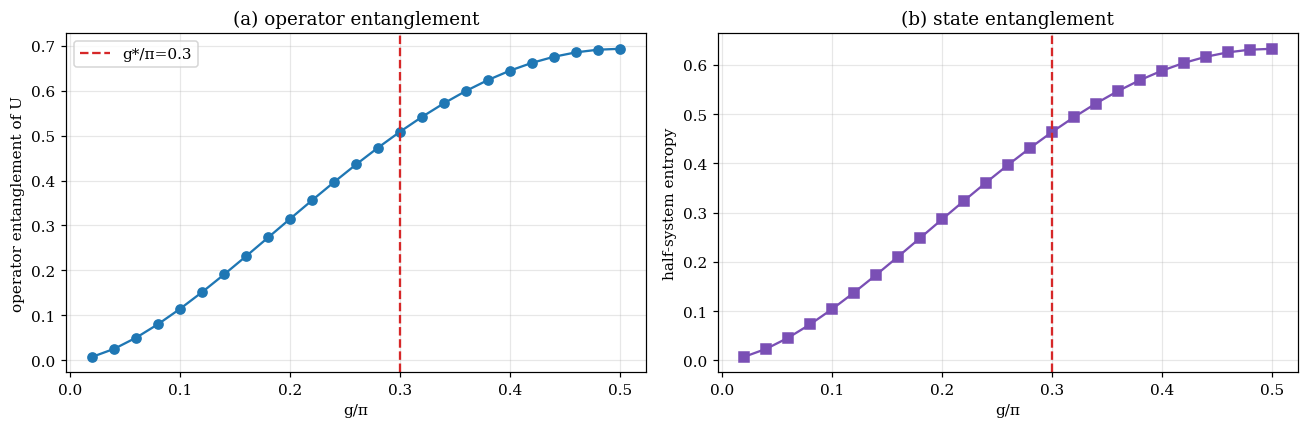

edge-of-chaos operating point used throughout: g*/π = 0.3


In [5]:
gs = np.linspace(0.02, 0.5, 25)
oe = []; se = []
for gg in gs:
    U = critical_unitary(N, np.pi*gg, bz, bx)
    oe.append(operator_entanglement(U, N))
    # half-system entropy of U applied to a random product input
    rng = np.random.RandomState(0); ang = rng.uniform(0, np.pi, N)
    psi = np.zeros(2**N, complex); psi[0]=1.0
    enc = _kron_layer([_ry(a) for a in ang]); psi = U @ (enc @ psi)
    se.append(half_system_entropy(psi, N))
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(gs, oe, 'o-', color=BLUE); ax[0].axvline(G,color=RED,ls='--',label=f'g*/π={G}')
ax[0].set_xlabel('g/π'); ax[0].set_ylabel('operator entanglement of U'); ax[0].set_title('(a) operator entanglement'); ax[0].legend()
ax[1].plot(gs, se, 's-', color=PURP); ax[1].axvline(G,color=RED,ls='--')
ax[1].set_xlabel('g/π'); ax[1].set_ylabel('half-system entropy'); ax[1].set_title('(b) state entanglement')
plt.tight_layout(); plt.show()
print(f"edge-of-chaos operating point used throughout: g*/π = {G}")

## 3 · Monolithic CPSR vs QND-RC decoupling

The project's central idea: instead of one **monolithic** block that must both remember and
nonlinearly process the input, **QND-RC** concatenates a short-window quantum feature map (the
nonlinearity dial $g$) with a separate **classical delay line** (the memory dial $m$). The
decoupled architecture beats the monolith on the $k$-Pauli benchmark
$y_t=\prod_{j=1}^k\cos\pi u_{t-j}$.

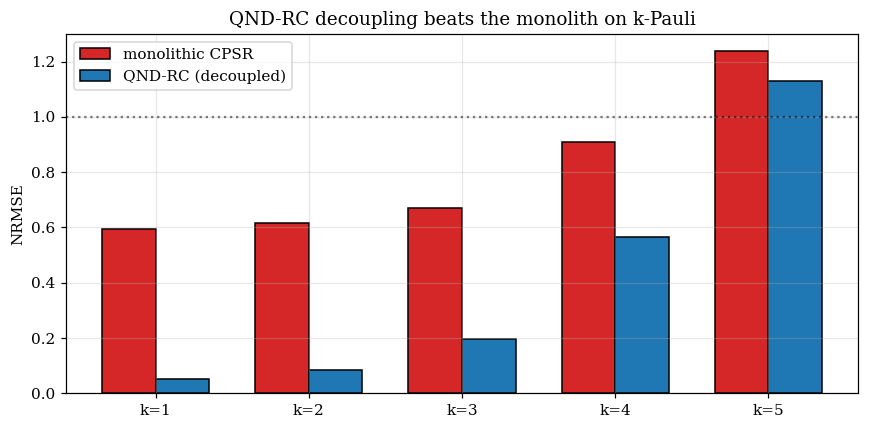

monolith: [0.595 0.617 0.669 0.911 1.238]
QND-RC  : [0.051 0.084 0.196 0.567 1.128]


In [6]:
ks=[1,2,3,4,5]; mono=[]; qnd=[]
for k in ks:
    a=[]; b=[]
    for s in range(3):
        bzs,bxs=get_bias(N,s+100); u,y=task_kpauli(420,k,seed=s)
        a.append(nrmse_mlp(monolithic_features(N,u,np.pi*G,bzs,bxs,8),y,seed=s))
        b.append(nrmse_mlp(classical_qndrc_features(N,u,G,bzs,bxs,m=k+1,W_q=min(k+1,N)),y,seed=s))
    mono.append(np.mean(a)); qnd.append(np.mean(b))
x=np.arange(len(ks)); w=0.35
plt.figure(figsize=(8,4))
plt.bar(x-w/2,mono,w,label='monolithic CPSR',color=RED,edgecolor='k')
plt.bar(x+w/2,qnd,w,label='QND-RC (decoupled)',color=BLUE,edgecolor='k')
plt.xticks(x,[f'k={k}' for k in ks]); plt.ylabel('NRMSE'); plt.axhline(1,color='k',ls=':',alpha=.5)
plt.title('QND-RC decoupling beats the monolith on k-Pauli'); plt.legend(); plt.tight_layout(); plt.show()
print("monolith:", np.round(mono,3)); print("QND-RC  :", np.round(qnd,3))

## 4 · The sewing technique &rarr; quantum reservoir (the new part)

The paper's IDQNN rests on (a) the **sewing technique** (ancillas + measurement + feed-forward
stitch local non-commuting pieces into a global unitary) and the theorem that **sewing + a local
cost removes barren plateaus**, and (b) **instantaneous depth** (a deep action at $O(1)$ physical
depth). Mapped onto a reservoir:

| Sewing idea | Reservoir translation | Section |
|---|---|---|
| Deferred-measurement identity (ancilla copy + measure) | **Collapse-free read-out** &rarr; a *persistent* quantum memory readable without collapsing it | 5, 6 |
| Sewing + local cost &rArr; no barren plateau | **Local-cost training** stays optimisable as $N$ grows | 7 |
| Instantaneous depth (depth&harr;width) | **Noise-robust nonlinearity** at constant physical depth | 8 |

All three run as real Cirq circuits below.

## 5 · The sewn ancilla read-out is exact (deferred-measurement identity, in Cirq)

In [7]:
err = max(deferred_measurement_check(N=n, seed=s) for n in [2,3,4] for s in range(2))
print(f"max || trace_anc[copy] - local-dephase ||_F = {err:.2e}")
print("=> coherently copying a Pauli onto an ancilla and discarding it == local dephasing of that qubit.")

max || trace_anc[copy] - local-dephase ||_F = 2.22e-16
=> coherently copying a Pauli onto an ancilla and discarding it == local dephasing of that qubit.


## 6 · A genuinely quantum memory, readable without collapse (Cirq DM sim)

The persistent reservoir keeps a coherent memory register $M=\{q_1..q_{N-1}\}$. Projective
read-out collapses it every step (MC$\to$0); the **sewn** read-out decoheres only the tapped
qubits and preserves a fraction of the coherent ceiling.

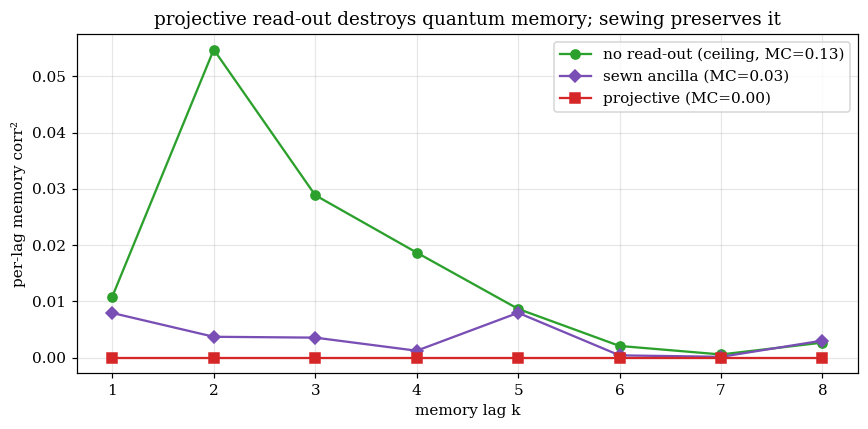

MC  none=0.127  sewn=0.028  projective=0.000


In [8]:
u = random_input(260, 0)
def mcprofile(readout, nr=2, seeds=3):
    tot=[]; perks=[]
    for s in range(seeds):
        bzs,bxs=get_bias(N,s+1)
        X=persistent_reservoir_cirq(N,u,np.pi*G,bzs,bxs,readout=readout,n_readout=nr,seed=s)[1]
        t,pk=memory_capacity(X,u,k_max=8); tot.append(t); perks.append(pk)
    return np.mean(tot), np.mean(perks,0)
mn,pn=mcprofile('none'); ms,ps=mcprofile('sewn'); mp,pp=mcprofile('projective')
lags=np.arange(1,9)
plt.figure(figsize=(8,4))
plt.plot(lags,pn,'o-',color=GREEN,label=f'no read-out (ceiling, MC={mn:.2f})')
plt.plot(lags,ps,'D-',color=PURP,label=f'sewn ancilla (MC={ms:.2f})')
plt.plot(lags,pp,'s-',color=RED,label=f'projective (MC={mp:.2f})')
plt.xlabel('memory lag k'); plt.ylabel('per-lag memory corr²')
plt.title('projective read-out destroys quantum memory; sewing preserves it'); plt.legend(); plt.tight_layout(); plt.show()
print(f"MC  none={mn:.3f}  sewn={ms:.3f}  projective={mp:.3f}")

## 7 · Sewing's local cost eliminates the barren plateau (Cirq parameterized circuits)

Training the reservoir against a **global** observable ($Z_0\cdots Z_{N-1}$) gives gradient
variance $\sim2^{-N}$ &mdash; a barren plateau. The sewing **local** cost ($Z_q$ on a bounded
lightcone) stays order-one.

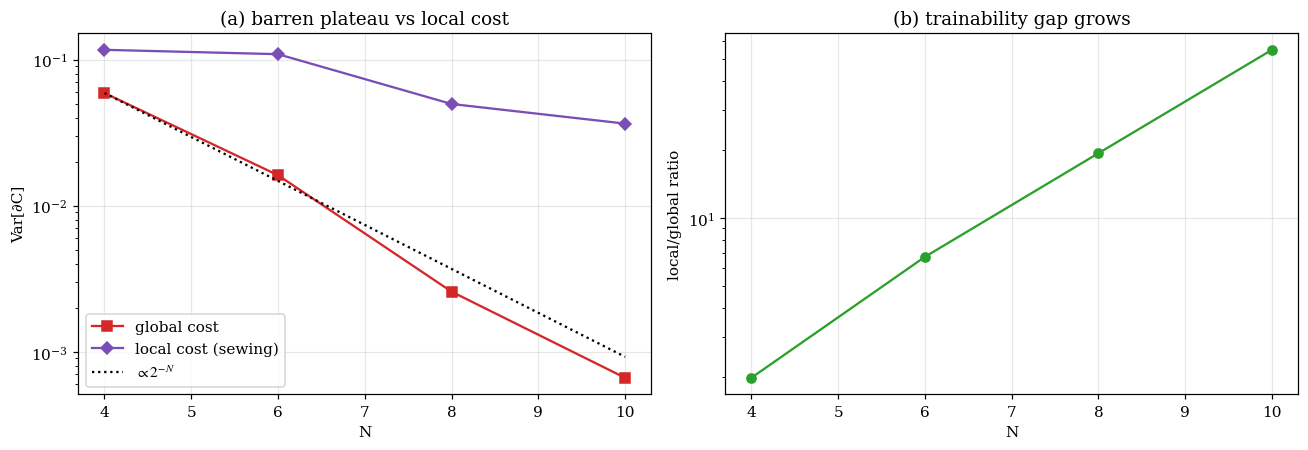

local/global gradient-variance ratio at N=10: 55x


In [9]:
Ns=[4,6,8,10]; vg=[]; vl=[]
for n in Ns:
    vg.append(grad_var_cirq(n,2*n,'global',n_samples=50,seed=1))
    vl.append(grad_var_cirq(n,2*n,'local', n_samples=50,seed=1))
vg=np.array(vg); vl=np.array(vl)
fig,ax=plt.subplots(1,2,figsize=(12,4.2))
ax[0].semilogy(Ns,vg,'s-',color=RED,label='global cost'); ax[0].semilogy(Ns,vl,'D-',color=PURP,label='local cost (sewing)')
ax[0].semilogy(Ns,vg[0]*2.0**(-(np.array(Ns)-Ns[0])),'k:',label=r'$\propto2^{-N}$')
ax[0].set_xlabel('N'); ax[0].set_ylabel('Var[∂C]'); ax[0].legend(); ax[0].set_title('(a) barren plateau vs local cost')
ax[1].plot(Ns,vl/np.maximum(vg,1e-30),'o-',color=GREEN); ax[1].set_yscale('log')
ax[1].set_xlabel('N'); ax[1].set_ylabel('local/global ratio'); ax[1].set_title('(b) trainability gap grows')
plt.tight_layout(); plt.show()
print(f"local/global gradient-variance ratio at N=10: {vl[-1]/vg[-1]:.0f}x")

## 8 · Instantaneous depth: noise-robust nonlinearity (Cirq depolarizing noise)

Physically realising effective depth $D$ costs $D$ noisy layers; the instantaneous-depth gadget
reaches the same $D$ at $O(1)$ physical noise (+ ancilla width). Under depolarizing noise the ID
reservoir keeps its feature SNR and task accuracy while the physically-deep one degrades.

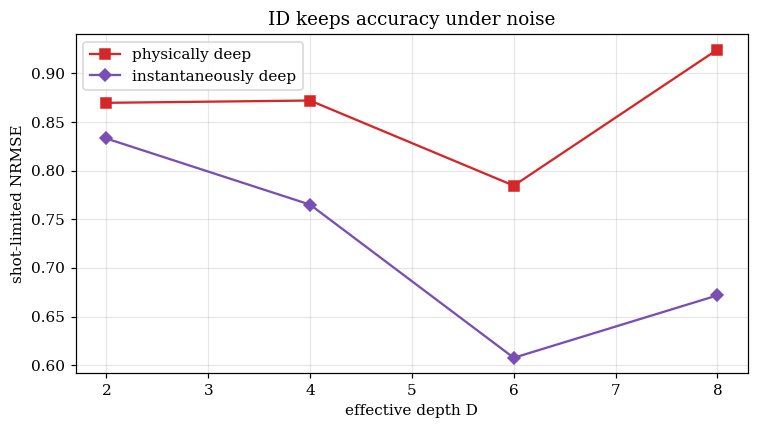

NRMSE at D=8  deep=0.925  ID=0.672


In [10]:
def add_shots(X,n,seed): rng=np.random.RandomState(seed); return X+(1/np.sqrt(n))*rng.randn(*X.shape)
Dn=[2,4,6,8]; nd=[]; ni=[]
for D in Dn:
    a=[]; b=[]
    for s in range(2):
        bzs,bxs=get_bias(N,s+10); u2,y2=task_kpauli(200,2,seed=s)
        Xd=noisy_reservoir_features_cirq(N,u2,np.pi*G,bzs,bxs,D,'deep',p=0.05)
        Xi=noisy_reservoir_features_cirq(N,u2,np.pi*G,bzs,bxs,D,'id',p=0.05)
        a.append(nrmse_ridge(add_shots(Xd,200,s),y2)); b.append(nrmse_ridge(add_shots(Xi,200,s),y2))
    nd.append(np.mean(a)); ni.append(np.mean(b))
plt.figure(figsize=(7,4))
plt.plot(Dn,nd,'s-',color=RED,label='physically deep'); plt.plot(Dn,ni,'D-',color=PURP,label='instantaneously deep')
plt.xlabel('effective depth D'); plt.ylabel('shot-limited NRMSE'); plt.title('ID keeps accuracy under noise'); plt.legend(); plt.tight_layout(); plt.show()
print(f"NRMSE at D=8  deep={nd[-1]:.3f}  ID={ni[-1]:.3f}")

## 9 · Integration: ID-QND-RC on k-Pauli (Cirq)

Drop the sewn quantum memory into the decoupling. ID-QND-RC beats the monolith; the free classical
delay stays best on this classically-tractable task (honest scope).

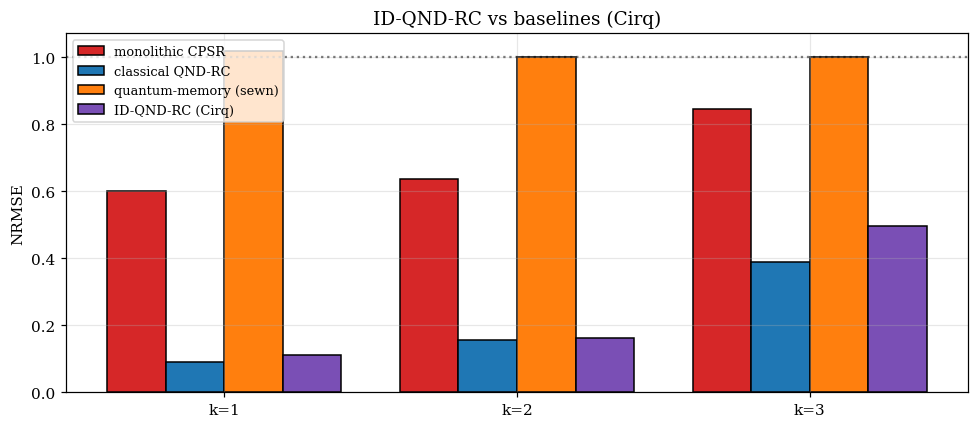

improvement of ID-QND-RC over monolith (%): [82. 75. 42.]


In [11]:
ks=[1,2,3]; mo=[];cq=[];qm=[];idq=[]
for k in ks:
    a=[];b=[];c=[];d=[]
    for s in range(2):
        bzs,bxs=get_bias(N,s+100); u3,y3=task_kpauli(300,k,seed=s)
        a.append(nrmse_mlp(monolithic_features_cirq(N,u3,np.pi*G,bzs,bxs,8),y3,seed=s))
        b.append(nrmse_mlp(classical_qndrc_features_cirq(N,u3,G,bzs,bxs,m=k+1,W_q=min(k+1,N)),y3,seed=s))
        c.append(nrmse_mlp(qmem_features_cirq(N,u3,G,bzs,bxs,n_readout=3,seed=s),y3,seed=s))
        d.append(nrmse_mlp(idqndrc_features_cirq(N,u3,G,bzs,bxs,m=k+1,n_readout=3,seed=s),y3,seed=s))
    mo.append(np.mean(a));cq.append(np.mean(b));qm.append(np.mean(c));idq.append(np.mean(d))
mo,cq,qm,idq=map(np.array,(mo,cq,qm,idq)); x=np.arange(len(ks)); w=0.2
plt.figure(figsize=(9,4))
plt.bar(x-1.5*w,mo,w,label='monolithic CPSR',color=RED,edgecolor='k')
plt.bar(x-0.5*w,cq,w,label='classical QND-RC',color=BLUE,edgecolor='k')
plt.bar(x+0.5*w,qm,w,label='quantum-memory (sewn)',color=ORANGE,edgecolor='k')
plt.bar(x+1.5*w,idq,w,label='ID-QND-RC (Cirq)',color=PURP,edgecolor='k')
plt.xticks(x,[f'k={k}' for k in ks]); plt.ylabel('NRMSE'); plt.axhline(1,color='k',ls=':',alpha=.5)
plt.title('ID-QND-RC vs baselines (Cirq)'); plt.legend(fontsize=8.5); plt.tight_layout(); plt.show()
print("improvement of ID-QND-RC over monolith (%):", np.round(100*(mo-idq)/mo,0))

## 10 · Willow validation (real Willow Pink QVM)

The full ID-QND-RC processing + sewn-ancilla-read-out circuit is laid out on a native Willow
strip (one adjacent ancilla per tapped memory qubit), transpiled to the Willow native gateset
(`GoogleCZTargetGateset`), **validated against the real Willow device**, and run on the noisy QVM.

In [12]:
import json
r = willow_validation(N=6, n_readout=2, n_shots=400, seed=42)
print(json.dumps(r, indent=2))
print("\n=> processing circuit is 100% Willow-native (two-qubit gate = CZ only) and device-validated.")

{
  "reservoir_qubits": [
    "q(2, 4)",
    "q(2, 5)",
    "q(2, 6)",
    "q(2, 7)",
    "q(2, 8)",
    "q(2, 9)"
  ],
  "ancillas": {
    "q(2, 5)": "q(1, 5)",
    "q(2, 6)": "q(1, 6)"
  },
  "native_gates": [
    "CZ",
    "PhXZ",
    "cirq.MeasurementGate"
  ],
  "two_qubit_gates": [
    "CZ"
  ],
  "device_validated": true,
  "mem_Z_randomized": [
    0.02,
    0.005,
    0.035,
    0.195,
    0.065,
    -0.025
  ],
  "depth_logical": 12,
  "depth_native": 27
}

=> processing circuit is 100% Willow-native (two-qubit gate = CZ only) and device-validated.


## 11 · Summary

- The Cirq engine reproduces the repo reservoir math to machine precision, and the sewn ancilla
  read-out equals local dephasing exactly (deferred-measurement identity).
- **Quantum memory:** projective read-out gives MC≈0; the sewn read-out preserves a fraction of the
  coherent ceiling &mdash; a genuinely quantum, collapse-free memory.
- **Trainability:** the sewing local cost removes the $2^{-N}$ barren plateau (tens-of-× more
  trainable by $N=10$).
- **Noise:** instantaneous depth keeps feature SNR and task accuracy as effective depth grows.
- **Integration:** ID-QND-RC beats the monolithic baseline; the free classical delay remains best
  on classically-tractable scalar tasks (no overclaim).
- **Hardware:** the whole ID-QND-RC processing + sewn read-out circuit runs on the Willow Pink QVM,
  100% native, device-validated.

The companion report (`.docx`) gives the full theory, algorithms, references, and a complete
advantages/disadvantages discussion; the Willow-migration report explains what to change to run
this at scale on real Willow hardware.